# 2. Periodic

In this notebook we show that tensor decoupling can be used with more complex functions than low-degree polynomials.

Let's define a periodic multivariate function.

In [1]:
import jax, jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme('notebook', 'white', palette='dark')

key = jax.random.key(0)
key_test = jax.random.key(0)

def target(x):
    x1, x2 = x
    return jnp.array([
        jnp.cos(3*jnp.pi*x1) + jnp.cos(jnp.pi*x2),
        2*jnp.sin(2*jnp.pi*x2) - jnp.sin(jnp.pi*x1),
    ])

We can plot each output for $x_1 = x_2$, to get an idea of the shape of this function.

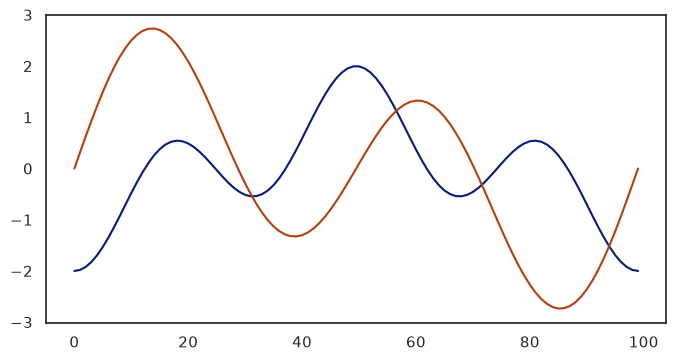

In [2]:
x = jnp.linspace(-1, 1, 100)
x = jnp.stack([x, x], axis=1)
Y = jax.vmap(target)(x)

plt.figure(figsize=(8, 4))
plt.plot(Y[:, 0])
plt.plot(Y[:, 1])
plt.show(); plt.close()

In [3]:
from decoupling.utils import collect_information_from_random

N = 100
info = collect_information_from_random(target, N, key, minval=-1.1, maxval=1.1)
X_test, _, _ = collect_information_from_random(target, N, key_test, minval=-1.0, maxval=1.0)
# it is often better to sample slightly out of the range of interest (here [-1, 1]),
# to get a smoother curve near the boundaries
info[2].shape

(2, 2, 100)

However, instead of the `basic_decoupling` algorithm used in the previous notebook, we will use a more powerful, B-spline-based algorithm called CMTF-BSD (from [this paper](https://arxiv.org/abs/2504.03263)).

In [4]:
from decoupling import Algorithm
from functools import partial

rank = 4

algo = Algorithm(rank, niters=100, splines_dof=25, ninits=3, key=key, use_smoothing=False)
decoupling = algo.run(*info)
print(f'Error: {algo.info.errors.min():.4f}')

[Seed 3/3]: 100%|████████████████████████████| 100/100 [00:00<00:00, 102.10it/s, error=0.0159, best=0.0112 (54), rcond=9.4e-02]


Error: 0.0112


In [5]:
from decoupling.utils import function_error

function_error(target, decoupling, X_test)

Array([4.4869127, 1.2437742], dtype=float32)

Both tensor and functions errors are quite low, indicating that our method managed to find a decent approximation of the target.
Lets plot the outputs to see if they match.

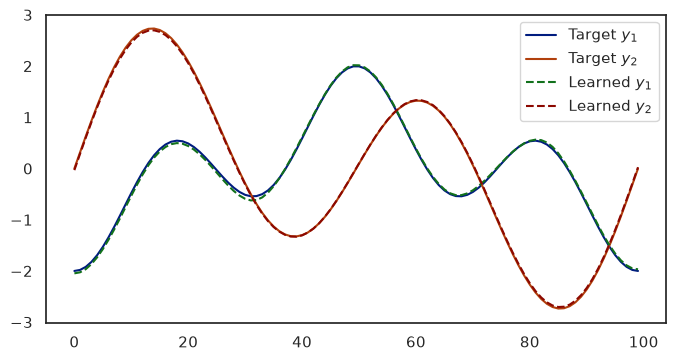

In [6]:
Ytarget = jax.vmap(target)(x)
Ylearned = jax.vmap(decoupling)(x)

plt.figure(figsize=(8, 4))
plt.plot(Ytarget[:, 0], label='Target $y_1$')
plt.plot(Ytarget[:, 1], label='Target $y_2$')
plt.plot(Ylearned[:, 0], label='Learned $y_1$', linestyle='--')
plt.plot(Ylearned[:, 1], label='Learned $y_2$', linestyle='--')
plt.legend(); plt.show(); plt.close()

That looks very good, the curves overlap almost perfectly!

Again, to get some insights about our target, we can look at the shapes of the internals of the returned decoupled model.

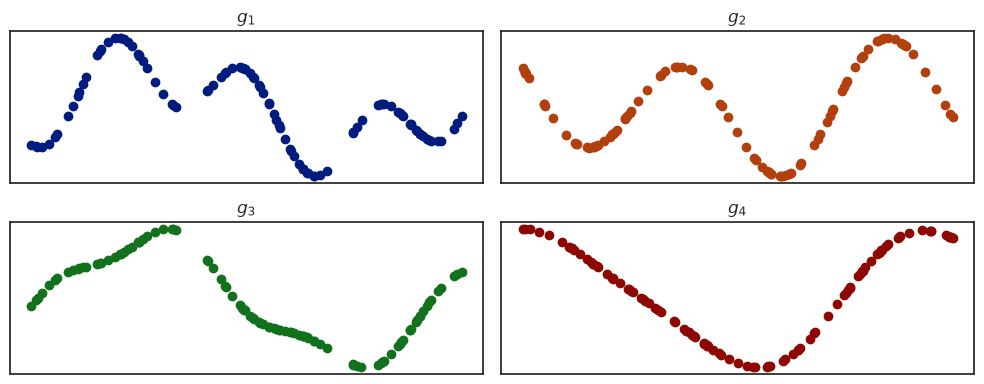

In [7]:
colors = sns.color_palette()

Z = info[0] @ decoupling.V
O = jax.vmap(decoupling.internals)(Z)

fig, ax = plt.subplots(2, 2, figsize=(10, 4))
for i, a in enumerate(ax.flatten()): 
    a.set_xticks([]); a.set_yticks([])
    a.scatter(Z[:, i], O[:, i], color=colors[i])
    a.set_title(f'$g_{i+1}$')

plt.tight_layout(); plt.show()